In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cols = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "class"]
df = pd.read_csv("./seeds/seeds_dataset.txt", names=cols, sep="\s+")

In [4]:
df.head()

,area,perimeter,compactness,length,width,asymmetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


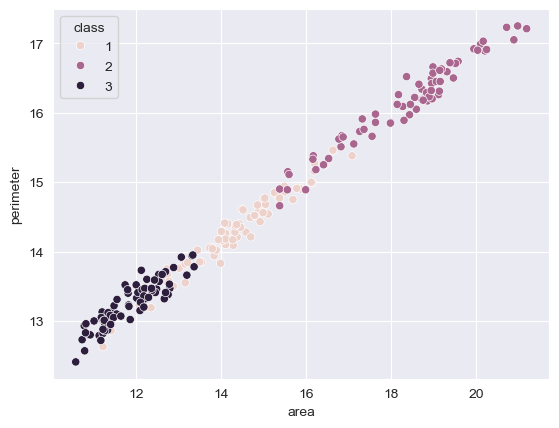

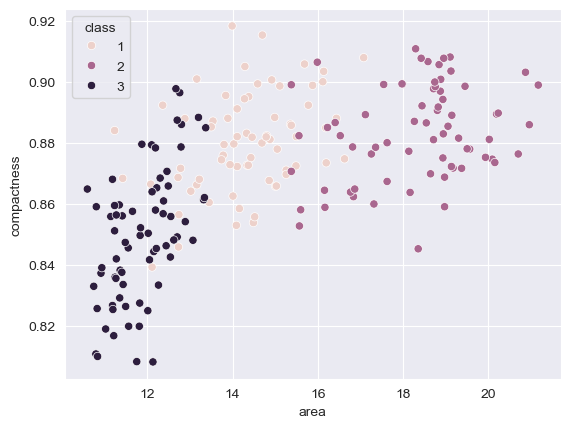

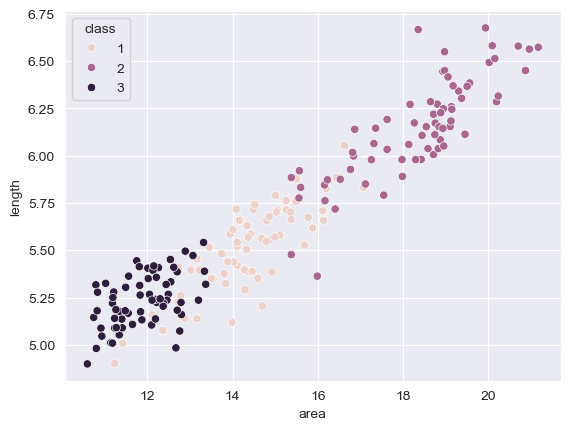

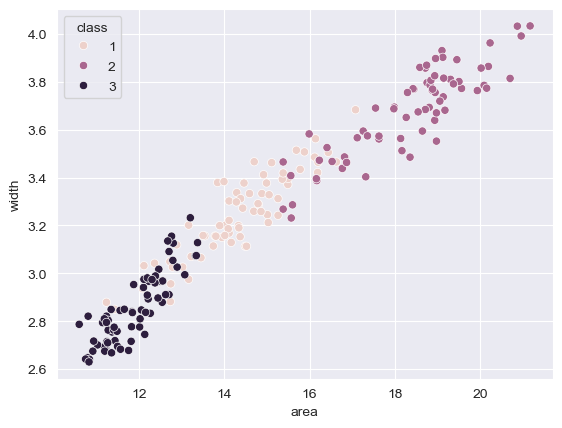

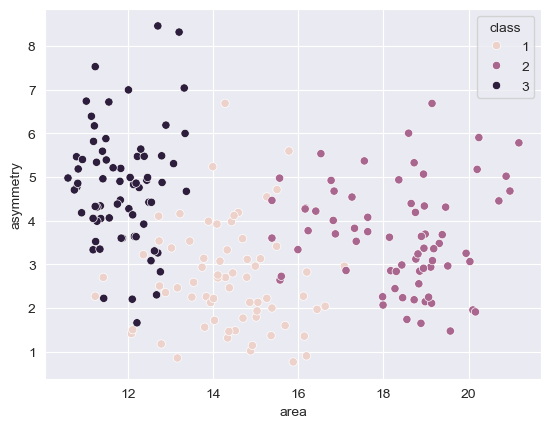

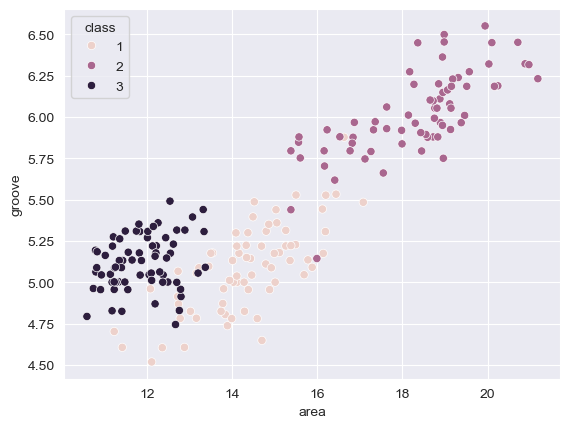

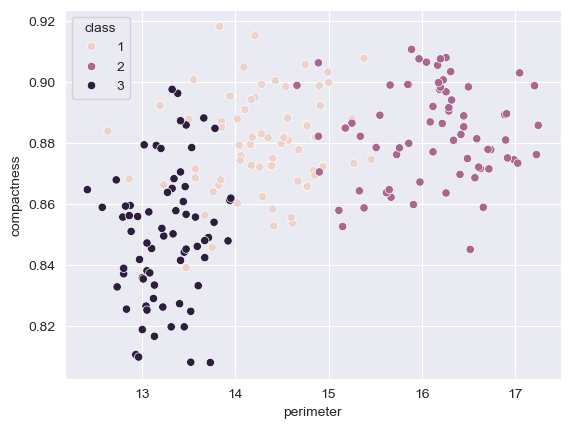

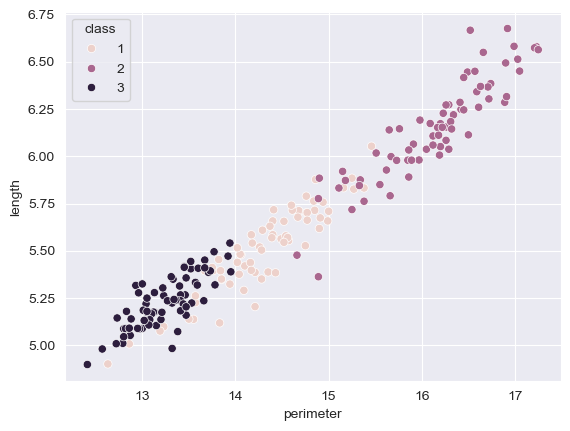

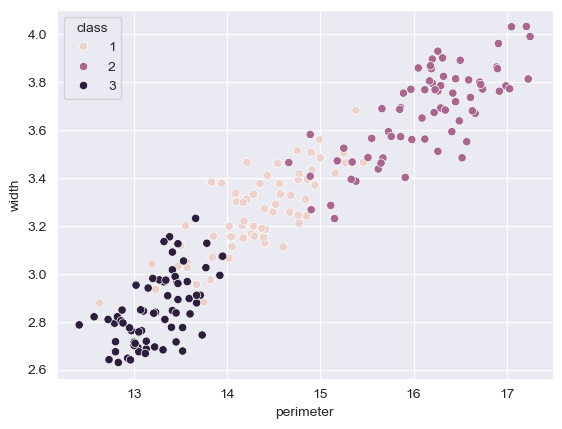

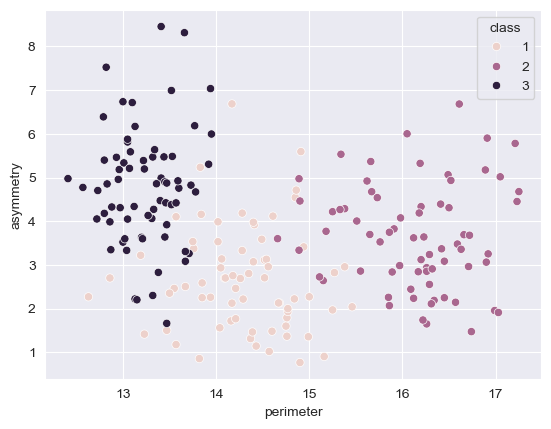

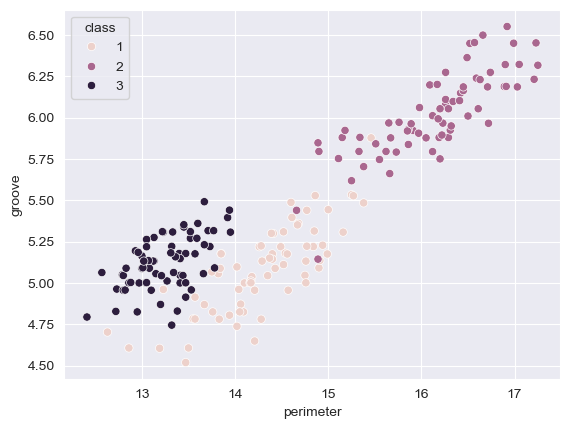

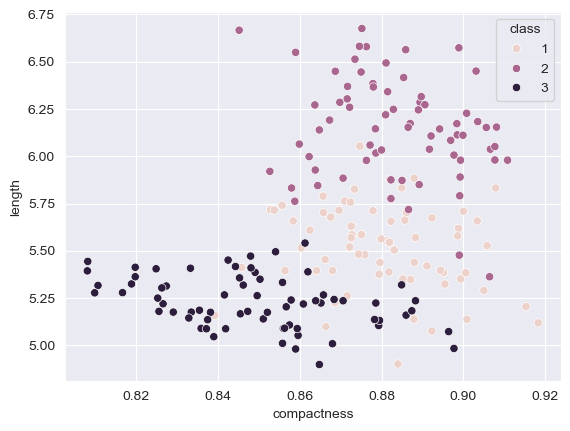

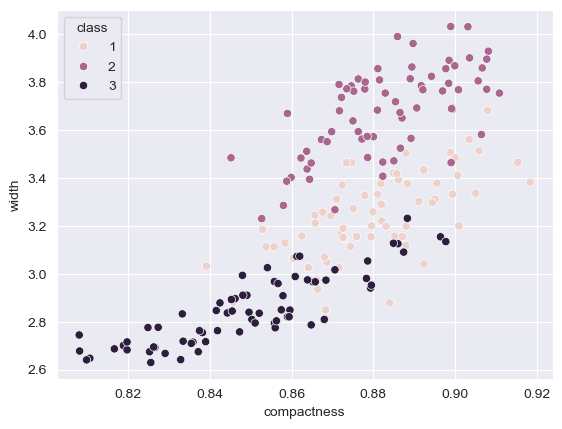

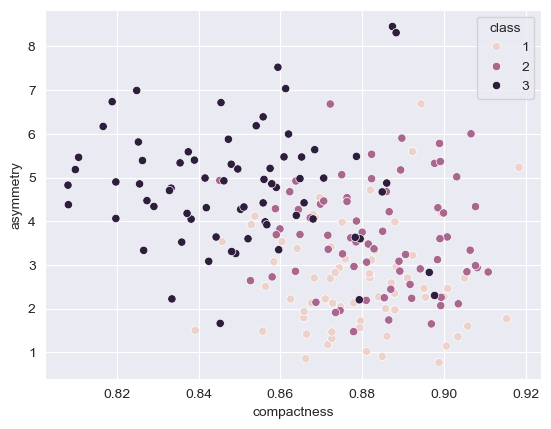

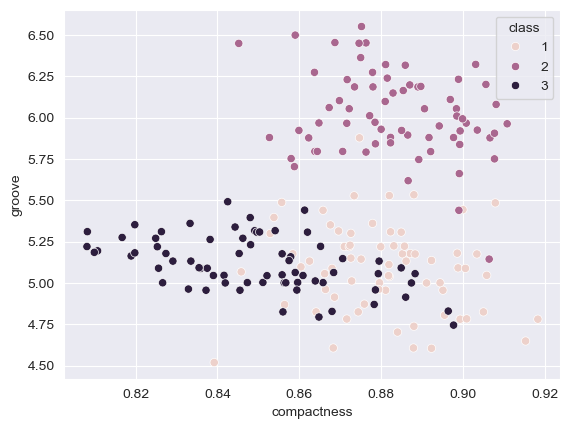

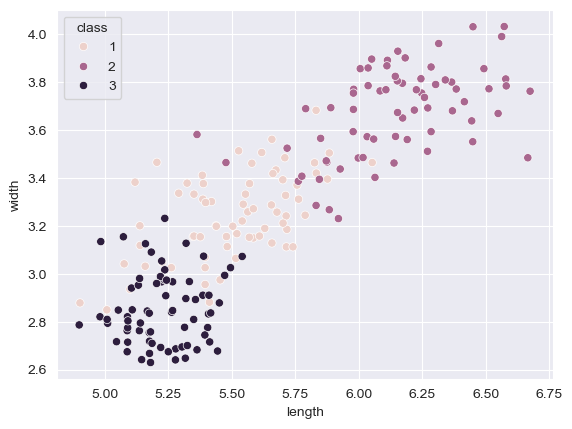

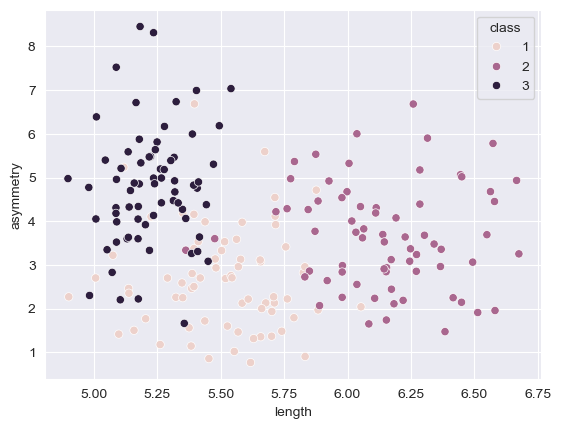

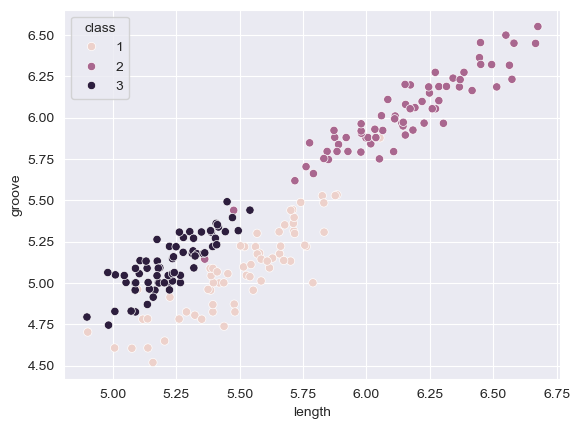

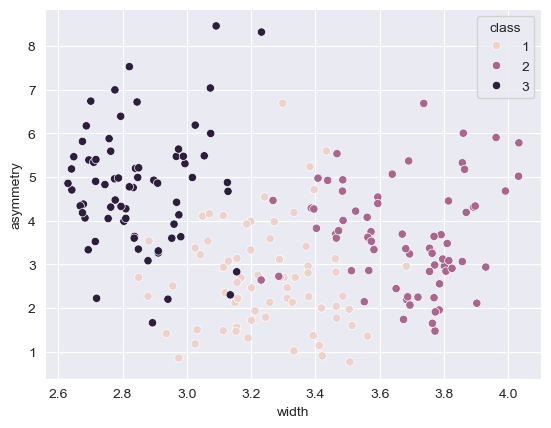

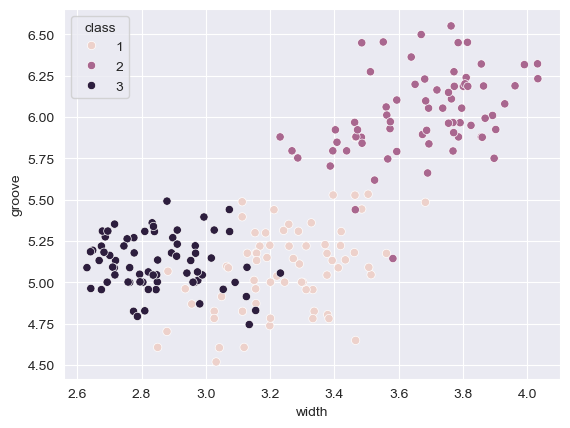

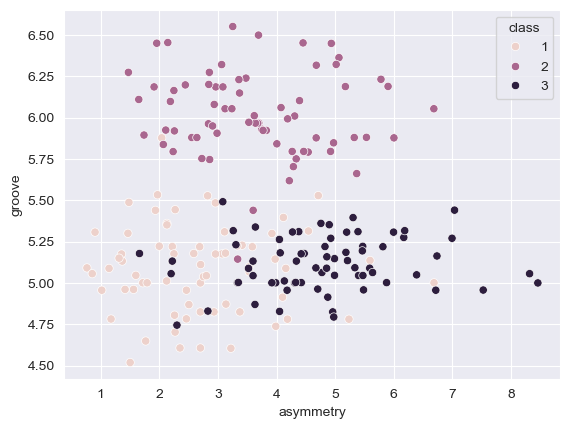

In [5]:
for i in range(len(cols)-1):
  for j in range(i+1, len(cols)-1):
    x_label = cols[i]
    y_label = cols[j]
    # 当 x/y/hue 给的是列名时，从该数据框中取相应列，此处为df
    sns.scatterplot(x=x_label, y=y_label, data=df, hue='class') # 按照c lass来进行颜色上区分
    plt.show()

# Clustering

In [6]:
from sklearn.cluster import KMeans

In [8]:
x = "compactness"
y = "asymmetry"
X = df[[x, y]].values
X

array([[0.871 , 2.221 ],
       [0.8811, 1.018 ],
       [0.905 , 2.699 ],
       [0.8955, 2.259 ],
       [0.9034, 1.355 ],
       [0.8951, 2.462 ],
       [0.8799, 3.586 ],
       [0.8911, 2.7   ],
       [0.8747, 2.04  ],
       [0.888 , 1.969 ],
       [0.8696, 4.543 ],
       [0.8796, 1.717 ],
       [0.888 , 3.986 ],
       [0.8759, 3.136 ],
       [0.8744, 2.932 ],
       [0.8993, 4.185 ],
       [0.9183, 5.234 ],
       [0.9058, 1.599 ],
       [0.9153, 1.767 ],
       [0.8686, 4.102 ],
       [0.8584, 3.072 ],
       [0.8722, 2.688 ],
       [0.8988, 0.7651],
       [0.8664, 1.415 ],
       [0.8657, 1.791 ],
       [0.8849, 0.903 ],
       [0.8641, 3.373 ],
       [0.8564, 2.504 ],
       [0.882 , 2.754 ],
       [0.8604, 3.531 ],
       [0.8662, 0.8551],
       [0.8724, 3.412 ],
       [0.8529, 3.92  ],
       [0.8728, 2.124 ],
       [0.8779, 2.129 ],
       [0.9   , 2.27  ],
       [0.8734, 2.823 ],
       [0.9079, 2.956 ],
       [0.8823, 3.112 ],
       [0.8944, 6.685 ],


In [12]:
kmeans = KMeans(n_clusters = 3).fit(X)
kmeans

D:\dev\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [11]:
clusters = kmeans.labels_
clusters

array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 2, 2, 1, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 2, 0, 0, 2, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       0, 0, 0, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2, 0, 0, 2,
       1, 1, 0, 2, 2, 1, 1, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 0,
       0, 2, 0, 1, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 2,
       2, 2, 1, 2, 2, 0, 0, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 0, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1,
       2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 2, 1], dtype=int32)

In [16]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1, 1))), columns=[x, y, "class"])
cluster_df

,compactness,asymmetry,class
0,0.8710,2.221,0.0
1,0.8811,1.018,0.0
2,0.9050,2.699,0.0
3,0.8955,2.259,0.0
4,0.9034,1.355,0.0
...,...,...,...
205,0.8783,3.631,2.0
206,0.8511,4.325,2.0
207,0.8883,8.315,1.0
208,0.8521,3.598,2.0


[]

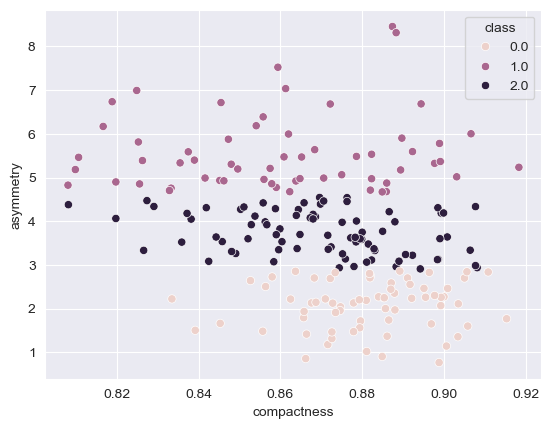

In [17]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

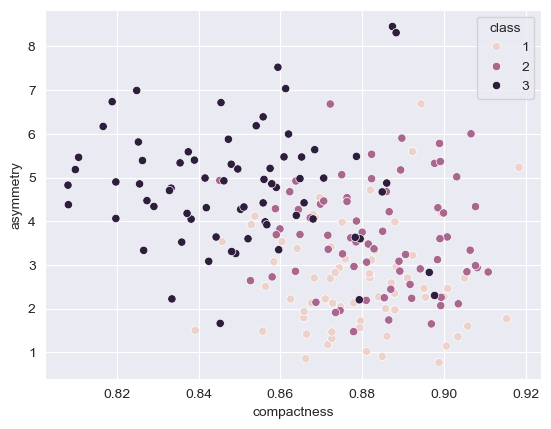

In [18]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

# Higher Dimensions

In [19]:
X = df[cols[:-1]].values
X

array([[15.26  , 14.84  ,  0.871 , ...,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811, ...,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 , ...,  3.337 ,  2.699 ,  4.825 ],
       ...,
       [13.2   , 13.66  ,  0.8883, ...,  3.232 ,  8.315 ,  5.056 ],
       [11.84  , 13.21  ,  0.8521, ...,  2.836 ,  3.598 ,  5.044 ],
       [12.3   , 13.34  ,  0.8684, ...,  2.974 ,  5.637 ,  5.063 ]])

In [22]:
kmeans = KMeans(n_clusters = 3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1, 1))), columns=df.columns)
cluster_df

D:\dev\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,area,perimeter,compactness,length,width,asymmetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1.0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1.0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1.0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1.0
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,0.0
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,0.0
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,0.0
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,0.0


[]

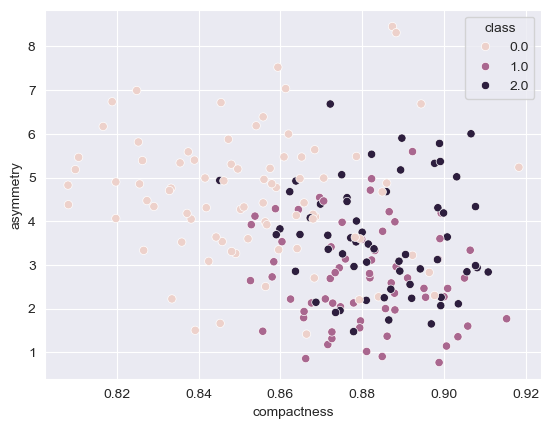

In [23]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

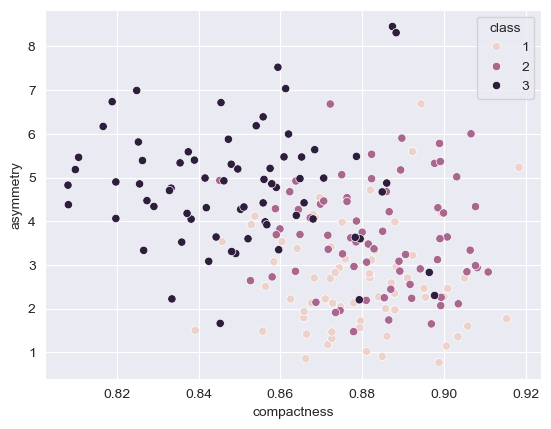

In [24]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

# PCA

In [31]:
from sklearn.decomposition import PCA

In [34]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)
transformed_x

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442],
       [-0.47693801, -1.33649437],
       [-0.18483472, -0.15036441],
       [-0.78062962, -1.12979883],
       [ 2.2821081 , -1.3600169 ],
       [ 1.97854147, -1.49468793],
       [ 0.36912295,  0.88672251],
       [-0.7110212 , -2.1066373 ],
       [-1.21370535,  0.09468789],
       [-1.16908541, -0.7429629 ],
       [-1.19272176, -0.95326816],
       [-0.50817121,  0.37795842],
       [-1.37469698,  1.32290559],
       [ 1.05726438, -2.01562875],
       [-0.1509611 , -2.02235813],
       [-2.46241293,  0.07374738],
       [-0.6313321 , -0.71830566],
       [-0.68969866, -1.11182531],
       [ 1.40769072, -2.80658086],
       [-2.84267672, -2.66880642],
       [ 0.43326822, -1.88984464],
       [ 1.81289158, -2.60002176],
       [-2.02131332, -0.60874333],
       [-2.19571862, -1.49837622],
       [-0.74446884,

In [35]:
X.shape

(210, 7)

In [36]:
transformed_x.shape

(210, 2)

In [37]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

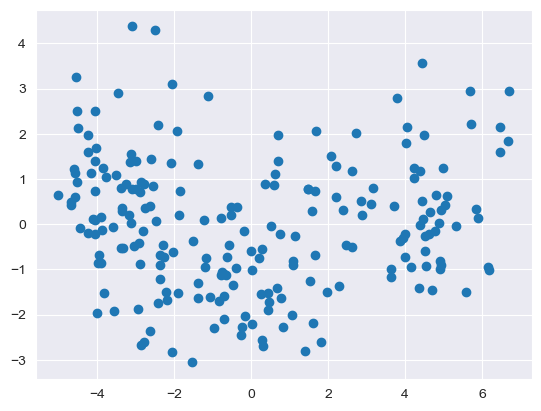

In [30]:
plt.scatter(transformed_x[:,0], transformed_x[:,1])
plt.show()

In [39]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1, 1))), columns=["pca1", "pca2", "class"])
kmeans_pca_df

,pca1,pca2,class
0,0.663448,-1.417321,1.0
1,0.315667,-2.689229,1.0
2,-0.660499,-1.131506,1.0
3,-1.055276,-1.621190,1.0
4,1.619999,-2.183384,1.0
...,...,...,...
205,-3.041872,-0.473126,0.0
206,-4.109063,0.109341,0.0
207,-2.500034,4.307965,0.0
208,-3.332079,-0.525290,0.0


In [38]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1, 1))), columns=["pca1", "pca2", "class"])
truth_pca_df

,pca1,pca2,class
0,0.663448,-1.417321,1.0
1,0.315667,-2.689229,1.0
2,-0.660499,-1.131506,1.0
3,-1.055276,-1.621190,1.0
4,1.619999,-2.183384,1.0
...,...,...,...
205,-3.041872,-0.473126,3.0
206,-4.109063,0.109341,3.0
207,-2.500034,4.307965,3.0
208,-3.332079,-0.525290,3.0


[]

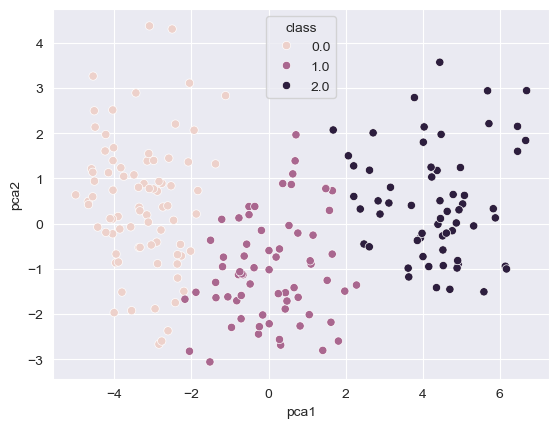

In [40]:
# K Means classes，不知道他要证明什么
sns.scatterplot(x="pca1", y="pca2", hue='class', data=kmeans_pca_df)
plt.plot()

[]

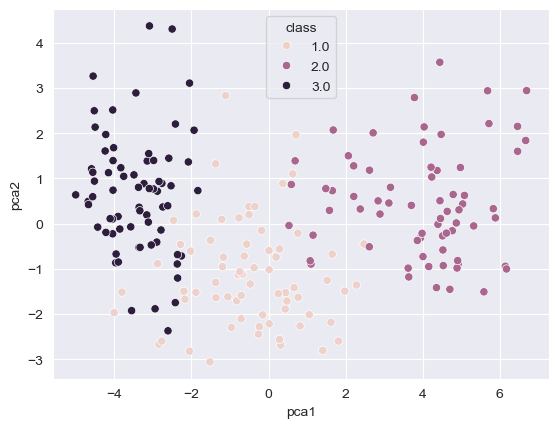

In [41]:
# Truth classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=truth_pca_df)
plt.plot()